<a href="https://colab.research.google.com/github/Zions86/Zions86/blob/main/Potato_Leaf_Disease_Detection_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [38]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
tf.keras.backend.clear_session()

#Load Dataset

In [39]:
import kagglehub

path = kagglehub.dataset_download("hafiznouman786/potato-plant-diseases-data")
print("Dataset Path:", path)

# Auto-detect correct folder
data_dir = None
for root, dirs, files in os.walk(path):
    if any("Potato" in d for d in dirs):
        data_dir = root
        break

print("Using Data Dir:", data_dir)
print("Classes:", os.listdir(data_dir))

Using Colab cache for faster access to the 'potato-plant-diseases-data' dataset.
Dataset Path: /kaggle/input/potato-plant-diseases-data
Using Data Dir: /kaggle/input/potato-plant-diseases-data
Classes: ['PlantVillage', 'PotatoPlants']


#Visualize Images

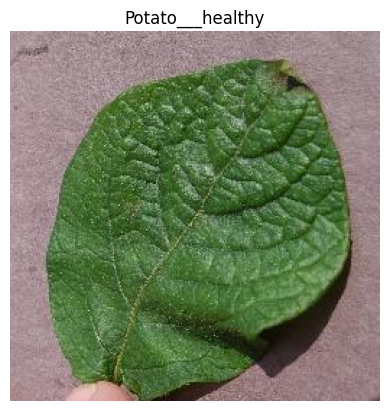

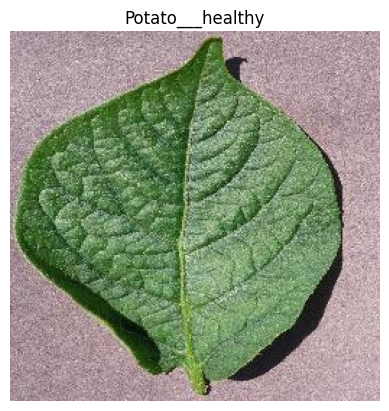

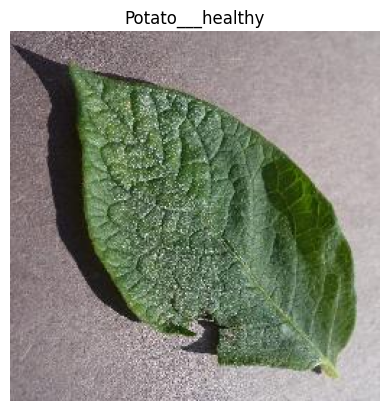

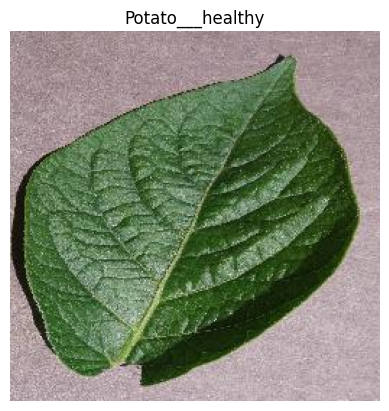

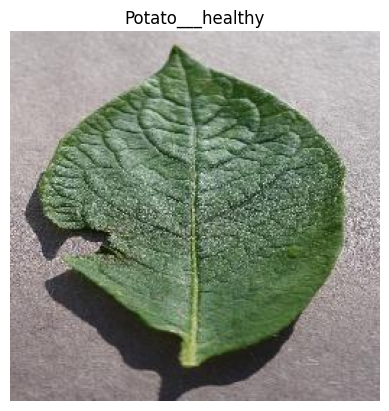

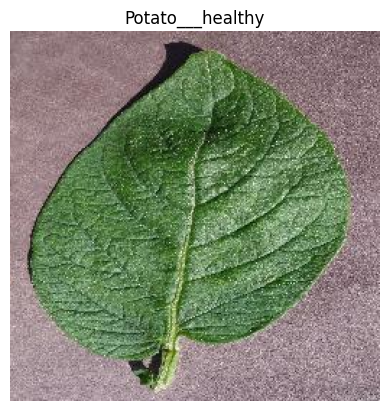

In [42]:
def get_sample_images(data_dir, num_images=3):
    images = []
    labels = []

    # Walk through all folders
    for root, dirs, files in os.walk(data_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, file)
                label = os.path.basename(root)  # folder name = class

                images.append(img_path)
                labels.append(label)

                if len(images) >= num_images:
                    return images, labels

    return images, labels


# Get sample images
image_paths, image_labels = get_sample_images(data_dir, num_images=6)

# Display images
for img_path, label in zip(image_paths, image_labels):
    img = cv2.imread(img_path)

    if img is None:
        print(f"❌ Failed to load: {img_path}")
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title(label)
    plt.axis("off")
    plt.show()

# Data Preprocessing

In [43]:
img_size = (128, 128)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='sparse',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='sparse',
    subset='validation'
)

Found 3444 images belonging to 2 classes.
Found 860 images belonging to 2 classes.


# Model Building (CNN)

In [45]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(3, activation='softmax'))
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

# Model Training

In [46]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.5090 - loss: 0.7274 - val_accuracy: 0.5000 - val_loss: 0.6946
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.4994 - loss: 0.7016 - val_accuracy: 0.5000 - val_loss: 0.6943
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.5073 - loss: 0.6986 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.4954 - loss: 0.6961 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.5195 - loss: 0.6944 - val_accuracy: 0.5000 - val_loss: 0.6968
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.4930 - loss: 0.6970 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.5093 - loss: 0.6948 - val_accuracy: 0.5000 - val_loss: 0.6961
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.5168 - loss: 0.6933 - val_accu

#Accuracy Graph

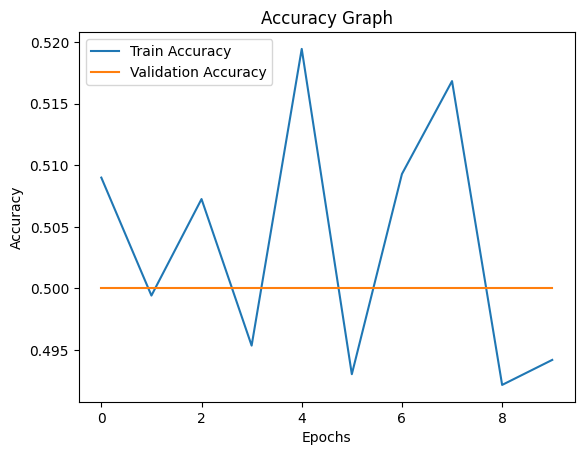

In [47]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.legend()
plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.show()

#Model Evaluation

In [48]:
val_data.reset()

pred = model.predict(val_data)
pred_classes = np.argmax(pred, axis=1)

true_classes = val_data.classes
class_labels = list(val_data.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(true_classes, pred_classes)
print("Confusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(true_classes, pred_classes, target_names=class_labels))

27/27 ━━━━━━━━━━━━━━━━━━━━ 17s 597ms/step
Confusion Matrix:
 [[  0 430]
 [  0 430]]

Classification Report:

              precision    recall  f1-score   support

PlantVillage       0.00      0.00      0.00       430
PotatoPlants       0.50      1.00      0.67       430

    accuracy                           0.50       860
   macro avg       0.25      0.50      0.33       860
weighted avg       0.25      0.50      0.33       860



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
